<a href="https://colab.research.google.com/github/JadHay8/ML-DL-Credit-Card-Fraud-Detectors/blob/main/detectors_pipeline_3fn3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Imports



In [ ]:
import time

start_time = time.time()

In [ ]:
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

##Loading Data

In [ ]:
import json
from google.colab import userdata

# Load the secret
kaggle_secret = userdata.get("KAGGLE_JSON")

# Create kaggle directory
!mkdir -p ~/.kaggle

# Write the secret to the file
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_secret)

# Fix permissions
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
! kaggle datasets download bannourchaker/frauddetection

Dataset URL: https://www.kaggle.com/datasets/bannourchaker/frauddetection
License(s): copyright-authors
 69% 122M/176M [00:00<00:00, 1.28GB/s]
100% 176M/176M [00:00<00:00, 999MB/s] 


In [ ]:
!unzip /content/frauddetection.zip

Archive:  /content/frauddetection.zip
  inflating: transactions_train.csv  


##Helper Functions

In [ ]:

def scale_dataset(X,y, scaler= 0.5, random_state=42):
    """
    Downsample the majority class to create a balanced dataset with
    'target_size' samples per class.
    """
    np.random.seed(random_state)

    # Convert y to numpy (keeps compatibility)
    y_np = np.asarray(y)


    # Get row indices for each class
    idx0 = np.where(y_np == 0)[0]
    idx1 = np.where(y_np == 1)[0]

    # Shuffle
    np.random.shuffle(idx0)
    np.random.shuffle(idx1)

    # How many non-fraud samples to keep
    new_size = int(len(idx0) * scaler)

    print(f"Original non-fraud: {len(idx0)}, fraud: {len(idx1)} ----> New non-fraud size: {new_size}")

    # ✅ Keep scaled non-fraud + ALL fraud
    keep_nonfraud = idx0[:new_size]
    keep_fraud = idx1
    keep_idx = np.concatenate([keep_nonfraud, keep_fraud])

    # Final shuffle
    np.random.shuffle(keep_idx)

    # Slice rows safely
    if isinstance(X, pd.DataFrame):
        X_scaled = X.iloc[keep_idx]
    else:
        X_scaled = X[keep_idx]

    if isinstance(y, pd.Series):
        y_scaled = y.iloc[keep_idx]
    else:
        y_scaled = y_np[keep_idx]

    return X_scaled, y_scaled

In [ ]:
def balance_dataset(X_train, y_train, random_state=42): #only want to balance the training set because we want the val and test set to reflect real-world distribution
    """
    Downsample the majority class to create a balanced dataset with
    'target_size' samples per class.
    """
    np.random.seed(random_state)

    # Convert y to numpy (keeps compatibility)
    y_np = np.asarray(y)


    # Get row indices for each class
    idx0 = np.where(y_np == 0)[0]
    idx1 = np.where(y_np == 1)[0]

    # Shuffle
    np.random.shuffle(idx0)
    np.random.shuffle(idx1)

    # Minority class size
    min_size = min(len(idx0), len(idx1))

    print(f"Min Class Size: {min_size} → Balanced Dataset Size: {min_size * 2}")

    # Select equal samples
    keep_idx = np.concatenate([idx0[:min_size], idx1[:min_size]])
    np.random.shuffle(keep_idx)

    # Slice rows safely
    if isinstance(X, pd.DataFrame):
        X_bal = X.iloc[keep_idx]
    else:
        X_bal = X[keep_idx]

    if isinstance(y, pd.Series):
        y_bal = y.iloc[keep_idx]
    else:
        y_bal = y_np[keep_idx]

    return X_bal, y_bal

In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(history):
    # Extract metrics
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])

    epochs = range(1, len(acc) + 1)

    # ---- Accuracy Plot ----
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs. Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def get_model_predictions(model, X_test, threshold=0.5):
    # Predict probabilities
    y_test_pred_proba = model.predict(X_test)

    # Convert probabilities to class labels (0/1)
    y_test_pred = (y_test_pred_proba >= threshold).astype(int).ravel()

    return y_test_pred


def get_metrics(y_test, y_test_pred):
    # -----------------------------
    # 1. Accuracy
    # -----------------------------
    accuracy = accuracy_score(y_test, y_test_pred)
    print("Accuracy:", accuracy)

    # -----------------------------
    # 2. Confusion Matrix
    # -----------------------------
    cm = confusion_matrix(y_test, y_test_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # -----------------------------
    # 3. Full Classification Report
    # -----------------------------
    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))
    return None

# Data Preprocessing


## Analyze Data

Visualize Data

In [ ]:
import pandas as pd
df = pd.read_csv("transactions_train.csv",encoding='ISO-8859-1')

df.head()

,step,type,amount,nameOrig,oldbalanceOrig,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [ ]:
df[df["isFraud"] == 1].head(5)
print(df[df["isFraud"] == 1].shape[0]) # number of frauds
df[df["isFraud"] == 0].shape[0] # number of non-fraud

7717


6343476

### Generate Data Dictionary

In [ ]:
import pandas as pd

# Get column names and their data types from the DataFrame 'df'
column_info = df.dtypes.reset_index()
column_info.columns = ['Column Name', 'Data Type']

# Add a placeholder for 'Description'
# You can fill in detailed descriptions manually after creating the file
column_info['Description'] = 'No description provided.'

# Reorder columns for clarity
column_info = column_info[['Column Name', 'Data Type', 'Description']]

# Save the DataFrame to a CSV file
output_filename = 'data_dictionary.csv'
column_info.to_csv(output_filename, index=False)

print(f"Data dictionary saved to {output_filename}")

display(column_info)

Data dictionary saved to data_dictionary.csv


,Column Name,Data Type,Description
0,step,int64,No description provided.
1,type,object,No description provided.
2,amount,float64,No description provided.
3,nameOrig,object,No description provided.
4,oldbalanceOrig,float64,No description provided.
5,newbalanceOrig,float64,No description provided.
6,nameDest,object,No description provided.
7,oldbalanceDest,float64,No description provided.
8,newbalanceDest,float64,No description provided.
9,isFraud,int64,No description provided.


EDA

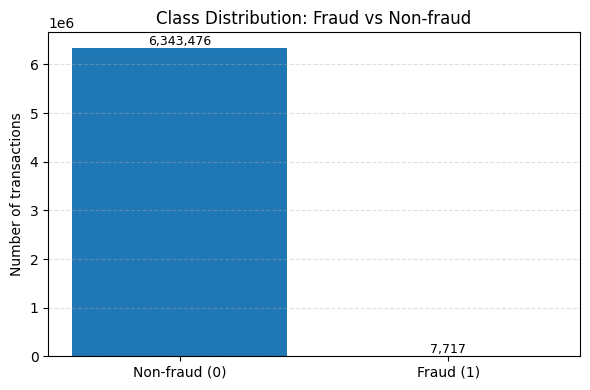

Fraud rate: 0.1215%


In [ ]:
class_counts = df["isFraud"].value_counts().sort_index()
labels = ["Non-fraud (0)", "Fraud (1)"]

plt.figure(figsize=(6, 4))
plt.bar(labels, class_counts.values)
plt.ylabel("Number of transactions")
plt.title("Class Distribution: Fraud vs Non-fraud")
for i, v in enumerate(class_counts.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

fraud_rate = class_counts.loc[1] / class_counts.sum()
print(f"Fraud rate: {fraud_rate:.4%}")

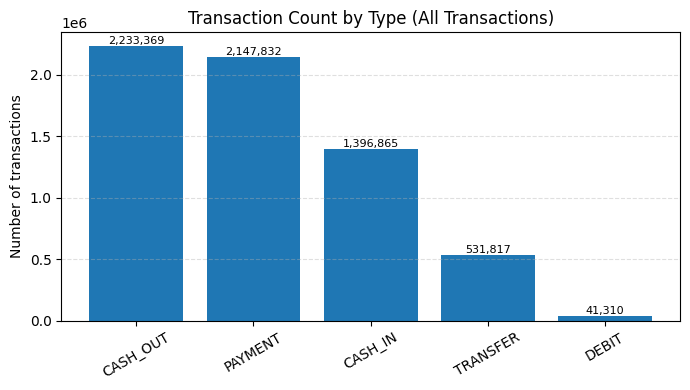

In [ ]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(type_counts.index, type_counts.values)
plt.ylabel("Number of transactions")
plt.title("Transaction Count by Type (All Transactions)")
for i, v in enumerate(type_counts.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

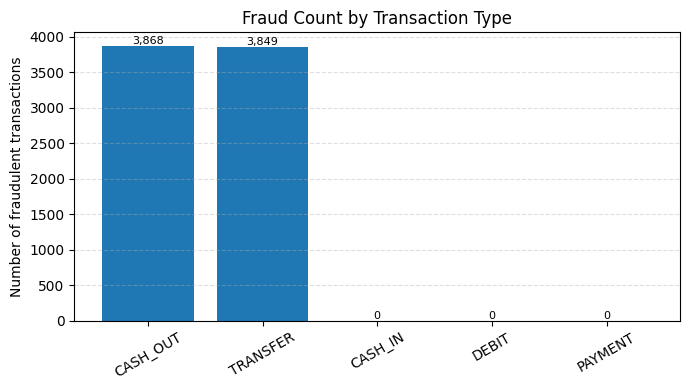

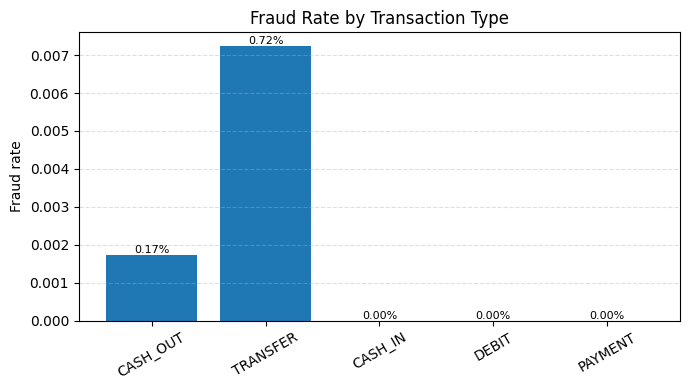

In [ ]:
# Fraud counts per type
fraud_by_type = df.groupby("type")["isFraud"].sum().sort_values(ascending=False)
total_by_type = df["type"].value_counts().loc[fraud_by_type.index]
fraud_rate_by_type = fraud_by_type / total_by_type

# (A) Fraud counts per type
plt.figure(figsize=(7, 4))
plt.bar(fraud_by_type.index, fraud_by_type.values)
plt.ylabel("Number of fraudulent transactions")
plt.title("Fraud Count by Transaction Type")
for i, v in enumerate(fraud_by_type.values):
    plt.text(i, v, f"{int(v):,}", ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# (B) Fraud rate per type
plt.figure(figsize=(7, 4))
plt.bar(fraud_rate_by_type.index, fraud_rate_by_type.values)
plt.ylabel("Fraud rate")
plt.title("Fraud Rate by Transaction Type")
for i, v in enumerate(fraud_rate_by_type.values):
    plt.text(i, v, f"{v:.2%}", ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

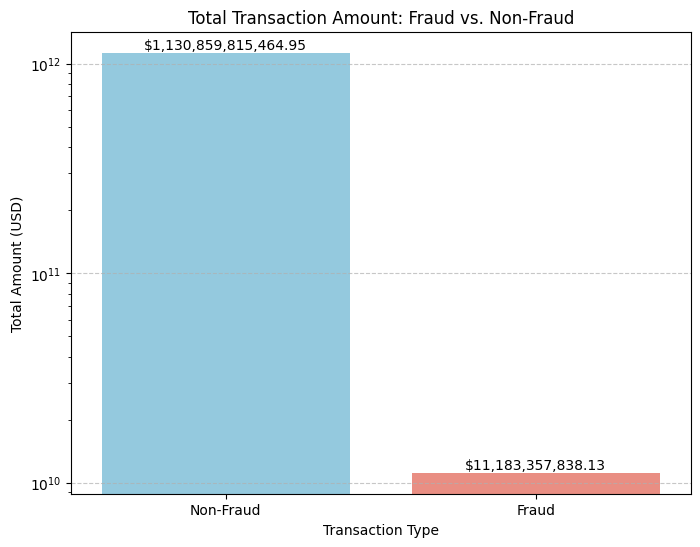

Total Non-Fraud Amount: 1130859815464.95
Total Fraud Amount: 11183357838.13
Proportion of total money that was fraudulent: 0.9792%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'isFraud' and sum the 'amount'
amount_by_fraud = df.groupby('isFraud')['amount'].sum().reset_index()
amount_by_fraud['isFraud'] = amount_by_fraud['isFraud'].map({0: 'Non-Fraud', 1: 'Fraud'})

# Plotting the total amounts
plt.figure(figsize=(8, 6))
sns.barplot(x='isFraud', y='amount', data=amount_by_fraud, palette={'Non-Fraud': 'skyblue', 'Fraud': 'salmon'}, hue='isFraud', legend=False)
plt.title('Total Transaction Amount: Fraud vs. Non-Fraud')
plt.xlabel('Transaction Type')
plt.ylabel('Total Amount (USD)')
plt.yscale('log') # Use a log scale due to potentially large differences
# Removed: plt.ticklabel_format(style='plain', axis='y') as it's incompatible with log scale
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for index, row in amount_by_fraud.iterrows():
    plt.text(index, row.amount, f'${row.amount:,.2f}', color='black', ha="center", va='bottom')

plt.show()

non_fraud_amount = amount_by_fraud[amount_by_fraud['isFraud'] == 'Non-Fraud']['amount'].iloc[0]
fraud_amount = amount_by_fraud[amount_by_fraud['isFraud'] == 'Fraud']['amount'].iloc[0]

print("Total Non-Fraud Amount:", non_fraud_amount)
print("Total Fraud Amount:", fraud_amount)

total_amount = non_fraud_amount + fraud_amount
proportion_fraudulent = fraud_amount / total_amount
print(f"Proportion of total money that was fraudulent: {proportion_fraudulent:.4%}")

Preparing Data

In [ ]:
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv("transactions_train.csv",encoding='ISO-8859-1')

# Label-encode categoricals
le_type = LabelEncoder()
le_name_orig = LabelEncoder()
le_name_dest = LabelEncoder()

df["type"] = le_type.fit_transform(df["type"])
df["nameOrig"] = le_name_orig.fit_transform(df["nameOrig"])
df["nameDest"] = le_name_dest.fit_transform(df["nameDest"])

# -------------------------
# 3. Create X and y
# -------------------------
X = df.drop(columns=["isFraud"])   # all input features
y = df["isFraud"]                  # labels



print(X.head())

   step  type    amount  nameOrig  oldbalanceOrig  newbalanceOrig  nameDest  \
0     1     3   9839.64    756432        170136.0       160296.36   1658347   
1     1     3   1864.28   2185056         21249.0        19384.72   1730065   
2     1     4    181.00   1000312           181.0            0.00    438228   
3     1     1    181.00   5817752           181.0            0.00    390383   
4     1     3  11668.14   3439787         41554.0        29885.86    826594   

   oldbalanceDest  newbalanceDest  
0             0.0             0.0  
1             0.0             0.0  
2             0.0             0.0  
3         21182.0             0.0  
4             0.0             0.0  


# Deep Learning Model

#### Models

MLP Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay

def build_mlp_small(n_features, lr=1e-3):

    #learning weight decay
    lr_schedule = ExponentialDecay(
        initial_learning_rate=lr,
        decay_steps=2000,      # how often to decay
        decay_rate=0.96,       # how much to decay each step
        staircase=True         # True = stepwise, False = continuous
    )
    optimizer = Adam(learning_rate=lr_schedule)

    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(n_features,)))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )
    return model



In [ ]:
from tensorflow.keras import regularizers
def build_mlp_large(n_features, lr=1e-3):

    #learning weight decay
    lr_schedule = ExponentialDecay(
        initial_learning_rate=lr,
        decay_steps=2000,      # how often to decay
        decay_rate=0.96,       # how much to decay each step
        staircase=True         # True = stepwise, False = continuous
    )
    optimizer = Adam(learning_rate=lr_schedule)

    l2_reg = regularizers.l2(1e-4)

    model = Sequential()
    #Block 1
    model.add(Dense(256, activation='relu', kernel_regularizer=l2_reg, input_shape=(n_features,)))
    model.add(Dropout(0.2))

    #Block 2
    model.add(Dense(128, activation='relu', kernel_regularizer=l2_reg))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2_reg))
    model.add(Dropout(0.2))

    #Block 3
    model.add(Dense(64, activation='relu', kernel_regularizer=l2_reg))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2_reg))
    model.add(Dropout(0.1))

    #output layer
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )
    return model


####Traiing Attempt 1: Training With Balanced Dataset on small mlp model

In [ ]:
# -----------------------------
# 1) Train (80%) + temp (20%)
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,      # temp pool for val + test
    random_state=42,
    stratify=y
)

# -----------------------------
# 2) Split temp → 10% val, 10% test
# temp contains 20%, so splitting 50/50 inside it gives 10/10
# -----------------------------
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,      # half of 20% = 10%
    random_state=42,
    stratify=y_temp
)

X_train_bal, y_train_bal = balance_dataset(X_train, y_train)

# -----------------------------
# 3) Scale features
# -----------------------------
scaler = StandardScaler()
X_train_bal = scaler.fit_transform(X_train_bal)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

Min Class Size: 7717 → Balanced Dataset Size: 15434


In [ ]:
print(len(X_train_bal))
print(len(X_val))
print(len(X_test))

15434
635119
635120


In [ ]:
#scale down test and val dataset since there are so many non fraud examples
X_val, y_val = scale_dataset(X_val,y_val, scaler= 0.1, random_state=42)
X_test, y_test = scale_dataset(X_test,y_test, scaler= 0.1, random_state=42)

print(len(X_val))
print(len(X_test))

Original non-fraud: 634348, fraud: 771 ----> New non-fraud size: 63434
Original non-fraud: 634348, fraud: 772 ----> New non-fraud size: 63434
64205
64206


In [ ]:
timesteps = 1 #each row is 1 timestep
n_features = X_train_bal.shape[1]
model = build_mlp_small(n_features=n_features, lr=0.001)

#Train
history_1 = model.fit(
    X_train_bal, y_train_bal,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    class_weight=None,
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7383 - loss: 0.5259 - val_accuracy: 0.8583 - val_loss: 0.3510
Epoch 2/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8590 - loss: 0.3274 - val_accuracy: 0.9102 - val_loss: 0.2713
Epoch 3/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8723 - loss: 0.2903 - val_accuracy: 0.9056 - val_loss: 0.2602
Epoch 4/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8858 - loss: 0.2558 - val_accuracy: 0.9303 - val_loss: 0.2238
Epoch 5/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8942 - loss: 0.2446 - val_accuracy: 0.9424 - val_loss: 0.1819
Epoch 6/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9058 - loss: 0.2224 - val_accuracy: 0.9458 - val_loss: 0.1836
Epoch 7/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9100 - loss: 0.2078 - val_accuracy: 0.9232 - val_loss: 0.2050
Epoch 8/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9190 - loss: 0.1910 - val_accuracy: 0.9569 - v

In [ ]:
y_test_pred = get_model_predictions(model, X_test)
get_metrics(y_test, y_test_pred)

2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Accuracy: 0.9429336822103853

Confusion Matrix:
[[59786  3648]
 [   16   756]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     63434
           1       0.17      0.98      0.29       772

    accuracy                           0.94     64206
   macro avg       0.59      0.96      0.63     64206
weighted avg       0.99      0.94      0.96     64206



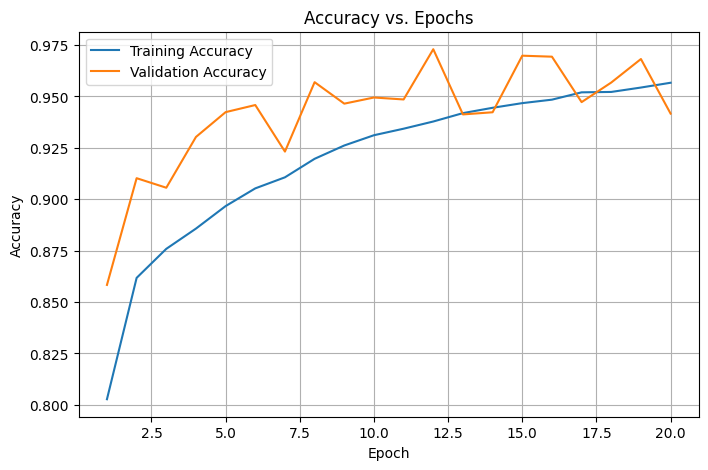

In [ ]:
plot_training_curves(history_1)

**Outcome:**

Since the training dataset was balanced the model learned to predict Fraud nearly as often as non fraud. Since this does not reflect the real world it's precision on fraud is really low, while its recall is not bad.

####Attempt 2: Training With class weights and small mlp model

In [ ]:
# -----------------------------
# 1) Train (80%) + temp (20%)
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,      # temp pool for val + test
    random_state=42,
    stratify=y
)

# -----------------------------
# 2) Split temp → 10% val, 10% test
# temp contains 20%, so splitting 50/50 inside it gives 10/10
# -----------------------------
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,      # half of 20% = 10%
    random_state=42,
    stratify=y_temp
)


# -----------------------------
# 3) Scale features
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [ ]:
#scale down test and val dataset since there are so many non fraud examples
X_train, y_train = scale_dataset(X_train,y_train, scaler= 0.1, random_state=42)
X_val, y_val = scale_dataset(X_val,y_val, scaler= 0.1, random_state=42)
X_test, y_test = scale_dataset(X_test,y_test, scaler= 0.1, random_state=42)

Original non-fraud: 5074780, fraud: 6174 ----> New non-fraud size: 507478
Original non-fraud: 634348, fraud: 771 ----> New non-fraud size: 63434
Original non-fraud: 634348, fraud: 772 ----> New non-fraud size: 63434


In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)   # ensures correct dtype + order

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights_dict = dict(zip(classes, class_weights))

print(f"class 1 (fraud) has weight of {class_weights_dict[1]}")
print(f"class 0 (not fraud) has weight of {class_weights_dict[0]}")


class 1 (fraud) has weight of 41.597991577583414
class 0 (not fraud) has weight of 0.5060830223182089


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
n_features = X_train.shape[1]
model = build_mlp_small(n_features=n_features,lr=0.001)

#early stopping
early_stop = EarlyStopping(
    monitor="accuracy",
    patience=5,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

#Train
history_2 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    class_weight=class_weights_dict ,
    callbacks = [early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
4013/4013 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8748 - loss: 0.3309 - val_accuracy: 0.9495 - val_loss: 0.1655
Epoch 2/20
4013/4013 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9361 - loss: 0.1825 - val_accuracy: 0.9548 - val_loss: 0.1476
Epoch 3/20
4013/4013 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9460 - loss: 0.1498 - val_accuracy: 0.9472 - val_loss: 0.1404
Epoch 4/20
4013/4013 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9453 - loss: 0.1335 - val_accuracy: 0.9751 - val_loss: 0.0821
Epoch 5/20
4013/4013 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9521 - loss: 0.1165 - val_accuracy: 0.9717 - val_loss: 0.0780
Epoch 6/20
4013/4013 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9540 - loss: 0.1085 - val_accuracy: 0.9579 - val_loss: 0.1010
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


In [ ]:
y_test_pred = get_model_predictions(model, X_test, threshold = 0.5)
get_metrics(y_test, y_test_pred)

2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Accuracy: 0.9506120923278198

Confusion Matrix:
[[60348  3086]
 [   85   687]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     63434
           1       0.18      0.89      0.30       772

    accuracy                           0.95     64206
   macro avg       0.59      0.92      0.64     64206
weighted avg       0.99      0.95      0.97     64206



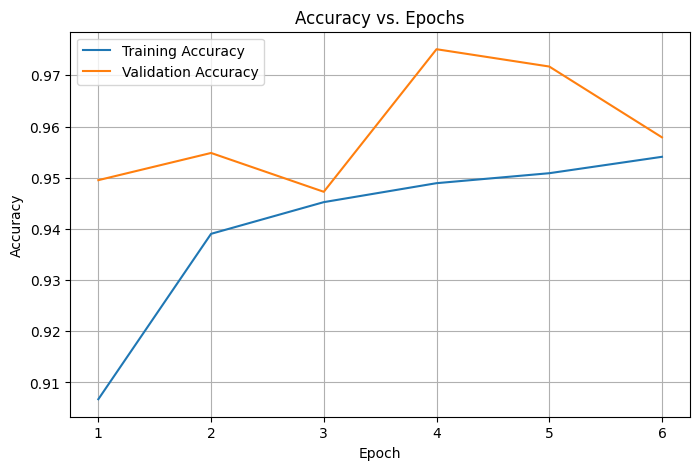

In [ ]:
plot_training_curves(history_2)

#### Attempt 3 Large MLP with weighted classes

In [ ]:
# from google.colab import files

# files.download('mlp_model.joblib')

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# Reshape
# -----------------------------
model = build_mlp_large(n_features=n_features,lr=0.001)


#early stopping
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    mode="max",
    verbose=1
)

#Train
history_3 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=128,
    class_weight=class_weights_dict,
    callbacks = [early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
4013/4013 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.8974 - loss: 0.3284 - val_accuracy: 0.9518 - val_loss: 0.2152
Epoch 2/100
4013/4013 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.9399 - loss: 0.2932 - val_accuracy: 0.9195 - val_loss: 0.1729
Epoch 3/100
4013/4013 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.9387 - loss: 0.1627 - val_accuracy: 0.9276 - val_loss: 0.1782
Epoch 4/100
4013/4013 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.9495 - loss: 0.1437 - val_accuracy: 0.9571 - val_loss: 0.1255
Epoch 5/100
4013/4013 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.9442 - loss: 0.1427 - val_accuracy: 0.9469 - val_loss: 0.1383
Epoch 6/100
4013/4013 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.9526 - loss: 0.1270 - val_accuracy: 0.9483 - val_loss: 0.1311
Epoch 7/100
4013/4013 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.9527 - loss: 0.1220 - val_accuracy: 0.9521 - val_loss: 0.1363
Epoch 8/100
4013/4013 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.9557 -

In [ ]:
# import joblib
# import os

# # Create a directory to store the models if it doesn't exist
# output_dir = "/content/drive/MyDrive/trained_models"
# os.makedirs(output_dir, exist_ok=True)

# filename = os.path.join(output_dir, f"mlp_model.joblib")

# joblib.dump(model, filename)

In [ ]:
val_scores = model.predict(X_val).ravel()

2007/2007 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [ ]:
from sklearn.metrics import f1_score
import numpy as np

best_t = 0
best_f1 = 0

for t in np.linspace(0, 1, 200):
    y_pred = (val_scores > t).astype(int)
    f1 = f1_score(y_val, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(best_t, best_f1)

0.964824120603015 0.9345430978613092


In [ ]:
y_test_pred = get_model_predictions(model, X_test, threshold = best_t)
get_metrics(y_test, y_test_pred)

2007/2007 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Accuracy: 0.99802199171417

Confusion Matrix:
[[63368    66]
 [   61   711]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     63434
           1       0.92      0.92      0.92       772

    accuracy                           1.00     64206
   macro avg       0.96      0.96      0.96     64206
weighted avg       1.00      1.00      1.00     64206



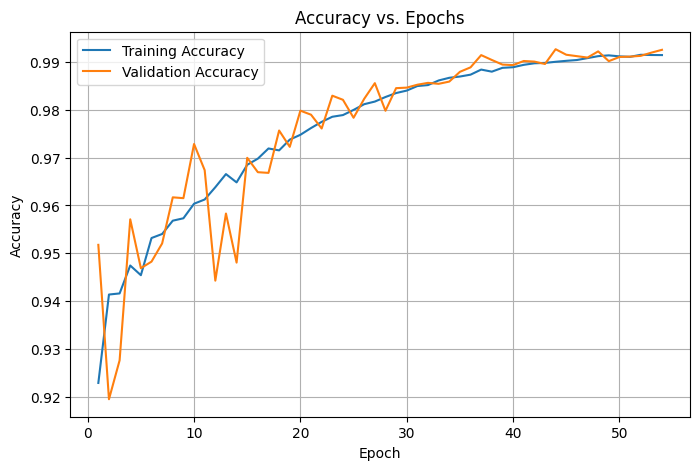

In [ ]:
plot_training_curves(history_3)



---





---



# Non-Deep Models

In [ ]:
import numpy as np
import pandas as pd
# Removed unused zipfile and os from the original script
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    classification_report
)
import xgboost as xgb
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

# For pandas display
pd.set_option("display.max_columns", 100)

Helper Functions

In [ ]:
def find_best_threshold(y_true, y_proba, beta=2.0):
    """
    Find threshold that maximizes F_beta score on validation probabilities.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    thresholds = thresholds  # length = len(precision) - 1

    best_thr = 0.5
    best_score = -1.0

    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))

        if tp == 0:
            continue

        prec = tp / (tp + fp)
        rec = tp / (tp + fn)

        if prec == 0 and rec == 0:
            f_beta = 0
        else:
            b2 = beta ** 2
            f_beta = (1 + b2) * (prec * rec) / (b2 * prec + rec)

        if f_beta > best_score:
            best_score = f_beta
            best_thr = thr

    return best_thr, best_score


def evaluate_model_on_set(name, fitted_pipeline, X, y, threshold=0.5):
    """
    Evaluate a fitted pipeline on a given dataset at default and tuned threshold.
    """
    y_proba = fitted_pipeline.predict_proba(X)[:, 1]
    y_pred_default = (y_proba >= 0.5).astype(int)
    y_pred_custom = (y_proba >= threshold).astype(int)

    roc = roc_auc_score(y, y_proba)
    pr = average_precision_score(y, y_proba)

    print(f"\n=== {name} | ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f} ===")

    print("\n-- Default threshold = 0.5 --")
    print("Confusion matrix:")
    print(confusion_matrix(y, y_pred_default))
    print("Classification report:")
    print(classification_report(y, y_pred_default, digits=4))

    print(f"\n-- Tuned threshold = {threshold:.4f} --")
    print("Confusion matrix:")
    print(confusion_matrix(y, y_pred_custom))
    print("Classification report:")
    print(classification_report(y, y_pred_custom, digits=4))

    return {"roc_auc": roc, "pr_auc": pr}

def plot_test_curves(name, y_true, y_proba, roc_auc, pr_auc):
    """Generates and displays the ROC and Precision-Recall curves."""

    # 1. ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color='grey')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Test Set)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(rec, prec, label=f"{name} (AP = {pr_auc:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve (Test Set)")
    plt.legend()
    plt.grid(True)
    plt.show()


def train_and_tune_models(models, X_train_bal, y_train_bal, X_val, y_val):
    """
    Trains all models on the balanced, transformed data (X_train_bal) and tunes the optimal threshold
    (F2) on the transformed validation set (X_val).
    """
    val_results = {}
    best_thresholds = {}

    for name, model in models.items():
        print(f"\n==================== Training & Tuning {name} ====================")

        # Fit model on balanced and transformed training data
        model.fit(X_train_bal, y_train_bal)

        # Predict on transformed validation data
        y_val_proba = model.predict_proba(X_val)[:, 1]

        roc = roc_auc_score(y_val, y_val_proba)
        pr = average_precision_score(y_val, y_val_proba)
        thr, f2 = find_best_threshold(y_val.values, y_val_proba, beta=2.0)

        val_results[name] = {
            "roc_auc": roc,
            "pr_auc": pr,
            "best_f2": f2,
            "best_thr": thr,
            "model": model # Store the trained model directly
        }
        best_thresholds[name] = thr

        print(f"Validation ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f}")
        print(f"Best F2 on val: {f2:.4f} at threshold {thr:.4f}")

    return val_results, best_thresholds


def select_and_evaluate_best_model(val_results, X_train_bal, y_train_bal, X_val, y_val, X_test, y_test, selection_metric="pr_auc"):
    """
    Selects the best model, retrains it on the combined TRAIN+VAL transformed data,
    and performs final evaluation on the TEST set.
    """
    # 1. Select Best Model
    best_model_name = max(val_results, key=lambda k: val_results[k][selection_metric])
    best_model = val_results[best_model_name]["model"]
    best_thr = val_results[best_model_name]["best_thr"]

    print(f"\n\n==================== Final Evaluation Setup ====================")
    print(f"Best model selected (by {selection_metric}): **{best_model_name}**")
    print(f"Using optimal threshold (from validation): {best_thr:.4f}")

    # 2. Retraining step is complex when dealing with pre-balanced data.
    # We rely on the model already fitted to the largest balanced dataset (X_train_bal).
    final_fitted_model = best_model

    # 3. Final Evaluation on TEST
    print("\n==================== Final Test Results ====================")
    test_results = evaluate_model_on_set(
        name=best_model_name,
        fitted_model=final_fitted_model,
        X_transformed=X_test,
        y=y_test,
        threshold=best_thr
    )

    return best_model_name, final_fitted_model, test_results, best_thr

Data Loading, Filtering and Cleanup

In [ ]:
df = pd.read_csv("transactions_train.csv", encoding='ISO-8859-1')


print("Raw shape:", df.shape)

# Filter to relevant transaction types
# relevant_types = ["CASH_OUT", "TRANSFER"]
# df_filtered = df[df["type"].isin(relevant_types)].copy()
# print("\nFiltered shape (CASH_OUT + TRANSFER):", df_filtered.shape)

# Drop ID-like columns (not used as features)
drop_cols = ["nameOrig", "nameDest"]
df.drop(columns=drop_cols, inplace=True)

# Target and Feature separation
X = df.drop(columns=["isFraud"])
y = df["isFraud"].astype(int)

print("\nFraud distribution (filtered):")
print(y.value_counts(normalize=True))

Raw shape: (6351193, 10)

Fraud distribution (filtered):
isFraud
0    0.998785
1    0.001215
Name: proportion, dtype: float64


Split Data

In [ ]:
# -----------------------------
# 1) Train (80%) + temp (20%)
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,      # temp pool for val + test
    random_state=42,
    stratify=y
)

# -----------------------------
# 2) Split temp → 10% val, 10% test
# temp contains 20%, so splitting 50/50 inside it gives 10/10
# -----------------------------
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,      # half of 20% = 10%
    random_state=42,
    stratify=y_temp
)

X_train_bal, y_train_bal = balance_dataset(X_train, y_train)

print(f"Train size: {y_train_bal.shape[0]} ({y_train_bal.value_counts(normalize=True)[1]:.4f} fraud)")
print(f"Val size:   {y_val.shape[0]} ({y_val.value_counts(normalize=True)[1]:.4f} fraud)")
print(f"Test size:  {y_test.shape[0]} ({y_test.value_counts(normalize=True)[1]:.4f} fraud)")

# Calculate scale_pos_weight for tree-based models
# neg = (y_train == 0).sum()
# pos = (y_train == 1).sum()
# scale_pos_weight = neg / pos
# print("\nscale_pos_weight (neg/pos):", scale_pos_weight)

Min Class Size: 7717 → Balanced Dataset Size: 15434
Train size: 15434 (0.5000 fraud)
Val size:   635119 (0.0012 fraud)
Test size:  635120 (0.0012 fraud)


Preprocessing Setup

In [ ]:
categorical_features = ["type"]
numeric_features = [c for c in X.columns if c not in categorical_features]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Define Models

In [ ]:
# neg = (y_train == 0).sum()
# pos = (y_train == 1).sum()
# scale_pos_weight = neg / pos
scale_pos_weight = class_weights_dict[0] / class_weights_dict[1]
print("\nscale_pos_weight (neg/pos):", scale_pos_weight)

# 8.1 Logistic Regression
log_reg = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            class_weight=class_weights_dict,
            max_iter=1000,
            n_jobs=-1,
            solver="lbfgs"
        ))
    ]
)

# 8.2 Random Forest
rf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            n_jobs=-1,
            class_weight=class_weights_dict,
            random_state=42
        ))
    ]
)

# 8.3 XGBoost
xgb_clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", xgb.XGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            n_jobs=-1,
            random_state=42
        ))
    ]
)

# 8.4 LightGBM
lgbm_clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LGBMClassifier(
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary",
            scale_pos_weight=scale_pos_weight,
            n_jobs=-1,
            random_state=42
        ))
    ]
)

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "XGBoost": xgb_clf,
    "LightGBM": lgbm_clf,
}



scale_pos_weight (neg/pos): 0.012166044636417737


Training and Tuning

In [ ]:
val_results = {}
best_thresholds = {}

for name, pipe in models.items():
    print(f"\n==================== {name} ====================")
    pipe.fit(X_train_bal, y_train_bal)

    y_val_proba = pipe.predict_proba(X_val)[:, 1]

    roc = roc_auc_score(y_val, y_val_proba)
    pr = average_precision_score(y_val, y_val_proba)

    # This takes too long to run
    # thr, f2 = find_best_threshold(y_val.values, y_val_proba, beta=2.0)
    # get_metrics(y_test, y_val_proba)

    val_results[name] = {
        "roc_auc": roc,
        "pr_auc": pr,
        # "best_f2": f2,
        # "best_thr": thr,
    }
    # best_thresholds[name] = thr

    print(f"Validation ROC-AUC: {roc:.4f}")
    print(f"Validation PR-AUC : {pr:.4f}")
    print()
    # print(f"Best F2 on val   : {f2:.4f} at threshold {thr:.4f}")


print("\n\n===== Validation Summary =====")
for name, res in val_results.items():
    print(
        f"{name:18s} | ROC-AUC: {res['roc_auc']:.4f} | "
        f"PR-AUC: {res['pr_auc']:.4f} | "
        # f"Best F2: {res['best_f2']:.4f} @ thr={res['best_thr']:.4f}"
    )



==================== Logistic Regression ====================
Validation ROC-AUC: 0.9798
Validation PR-AUC : 0.5005


==================== Random Forest ====================
Validation ROC-AUC: 0.9999
Validation PR-AUC : 0.9582


==================== XGBoost ====================
Validation ROC-AUC: 0.9984
Validation PR-AUC : 0.8893


==================== LightGBM ====================
[LightGBM] [Info] Number of positive: 7717, number of negative: 7717
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001364 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1540
[LightGBM] [Info] Number of data points in the train set: 15434, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation ROC-AUC: 0.9999
Validation PR-AUC : 0.9324



===== Validation Summary =====
Logistic Regression | ROC-AUC: 0.9798 | PR-AUC: 0.5005 | 
Random Forest      | ROC-AUC: 0.9999 | PR-AUC: 0.9582 | 
XGBoost            | ROC-AUC: 0.9984 | PR-AUC: 0.8893 | 
LightGBM           | ROC-AUC: 0.9999 | PR-AUC: 0.9324 | 


Save Model State

In [ ]:
# import joblib
# import os

# # Create a directory to store the models if it doesn't exist
# output_dir = "trained_models"
# os.makedirs(output_dir, exist_ok=True)

# print("\n\n===== Saving Trained Models =====")

# # Iterate over the dictionary containing the *trained* pipelines
# for name, pipe in models.items():
#     # Sanitize the name for use as a filename
#     safe_name = name.lower().replace(" ", "_")
#     filename = os.path.join(output_dir, f"{safe_name}_pipeline.joblib")

#     # Save the entire Pipeline object
#     joblib.dump(pipe, filename)
#     print(f"✅ Successfully saved '{name}' to: {filename}")

Load State

In [ ]:
# import joblib
# import os

# model_to_load = "Random Forest"
# safe_name = model_to_load.lower().replace(" ", "_")
# filename = os.path.join("trained_models", f"{safe_name}_pipeline.joblib")

# print(f"\n\n===== Loading Model: {model_to_load} =====")

# # Load the entire Pipeline object
# loaded_pipeline = joblib.load(filename)
# print(f"✅ Successfully loaded '{model_to_load}'.")

# # You can now use the loaded pipeline directly for new predictions
# # new_predictions = loaded_pipeline.predict(X_new)
# # new_probabilities = loaded_pipeline.predict_proba(X_new)[:, 1]

Find Best Model and Evaluate on Test

In [ ]:
best_model_name = max(val_results, key=lambda k: val_results[k]["pr_auc"])
best_model_name = "Random Forest"
best_model = models[best_model_name]
# best_thr = best_thresholds[best_model_name]

print(f"\nBest model selected: {best_model_name}")
# print(f"Using threshold (from validation): {best_thr:.4f}")

# Combine train + val
X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

best_model.fit(X_train_final, y_train_final)


# ============================================================
# 11. Final evaluation on TEST
# ============================================================

test_metrics = evaluate_model_on_set(
    name=best_model_name,
    fitted_pipeline=best_model,
    X=X_test,
    y=y_test,
    threshold=0.77
)


Best model selected: Random Forest

=== Random Forest | ROC-AUC: 0.9985 | PR-AUC: 0.9454 ===

-- Default threshold = 0.5 --
Confusion matrix:
[[634324     24]
 [   150    622]]
Classification report:
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999    634348
           1     0.9628    0.8057    0.8773       772

    accuracy                         0.9997    635120
   macro avg     0.9813    0.9028    0.9386    635120
weighted avg     0.9997    0.9997    0.9997    635120


-- Tuned threshold = 0.7700 --
Confusion matrix:
[[634344      4]
 [   208    564]]
Classification report:
              precision    recall  f1-score   support

           0     0.9997    1.0000    0.9998    634348
           1     0.9930    0.7306    0.8418       772

    accuracy                         0.9997    635120
   macro avg     0.9963    0.8653    0.9208    635120
weighted avg     0.9997    0.9997    0.9996    635120



### Comparison of Precision and Recall for Fraud Detection Models

Plot Results

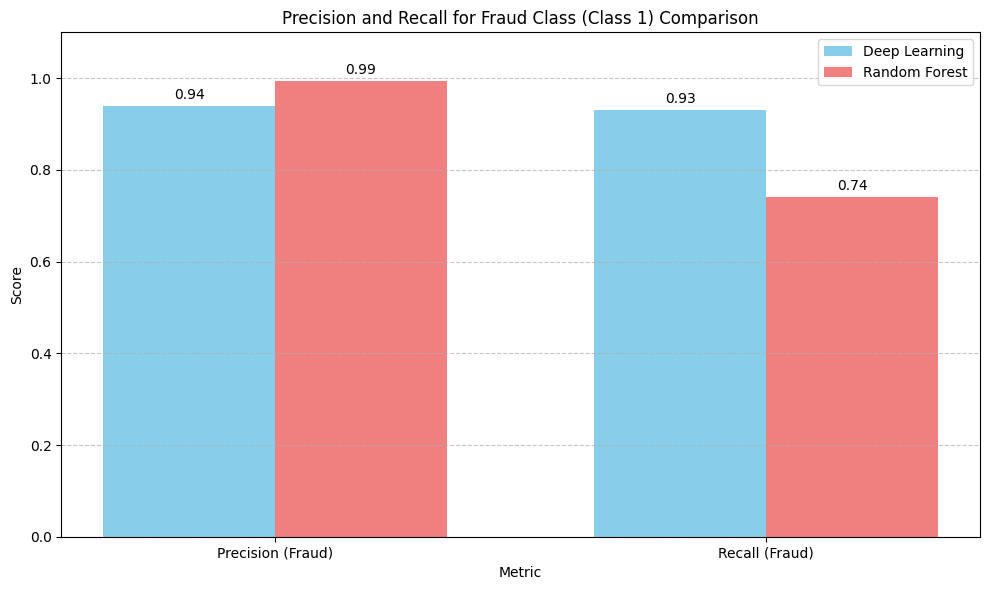

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data for comparison
data = {
    'Model': ['Deep Learning', 'Deep Learning', 'Random Forest', 'Random Forest'],
    'Metric': ['Precision (Fraud)', 'Recall (Fraud)', 'Precision (Fraud)', 'Recall (Fraud)'],
    'Score': [0.94, 0.93, 0.9931, 0.7409]
}
df_metrics = pd.DataFrame(data)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = np.arange(len(df_metrics['Metric'].unique()))

# Filter data for each model
df_dl = df_metrics[df_metrics['Model'] == 'Deep Learning']
df_rf = df_metrics[df_metrics['Model'] == 'Random Forest']

# Bars for Deep Learning model
rects1 = ax.bar(index - bar_width/2, df_dl['Score'], bar_width, label='Deep Learning', color='skyblue')

# Bars for Random Forest model
rects2 = ax.bar(index + bar_width/2, df_rf['Score'], bar_width, label='Random Forest', color='lightcoral')

# Add values on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Precision and Recall for Fraud Class (Class 1) Comparison')
ax.set_xticks(index)
ax.set_xticklabels(df_metrics['Metric'].unique())
ax.legend()
ax.set_ylim(0.0, 1.1) # Adjusted y-limit to accommodate labels

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

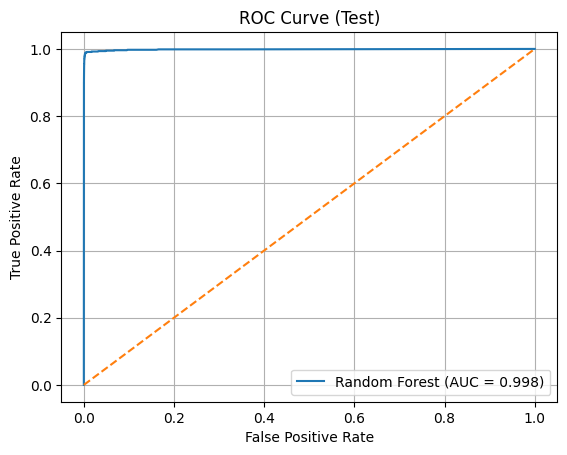

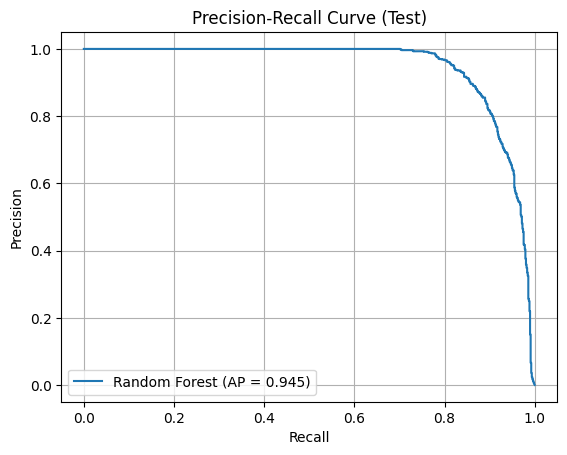

In [ ]:
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {test_metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_test_proba)
plt.figure()
plt.plot(rec, prec, label=f"{best_model_name} (AP = {test_metrics['pr_auc']:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Test)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
pr_auc_data = []

for model_name, metrics in val_results.items():
    pr_auc = metrics['pr_auc']
    pr_auc_data.append({'Model': model_name, 'PR-AUC': pr_auc})

print("Extracted PR-AUC data:")
for item in pr_auc_data:
    print(item)

Extracted PR-AUC data:
{'Model': 'Logistic Regression', 'PR-AUC': np.float64(0.5005006696894239)}
{'Model': 'Random Forest', 'PR-AUC': np.float64(0.9581521602300053)}
{'Model': 'XGBoost', 'PR-AUC': np.float64(0.8893022614149884)}
{'Model': 'LightGBM', 'PR-AUC': np.float64(0.9324372063955959)}


In [ ]:
import pandas as pd

df_pr_auc = pd.DataFrame(pr_auc_data)

print("PR-AUC DataFrame created:")
display(df_pr_auc)

PR-AUC DataFrame created:


,Model,PR-AUC
0,Logistic Regression,0.500501
1,Random Forest,0.958152
2,XGBoost,0.889302
3,LightGBM,0.932437


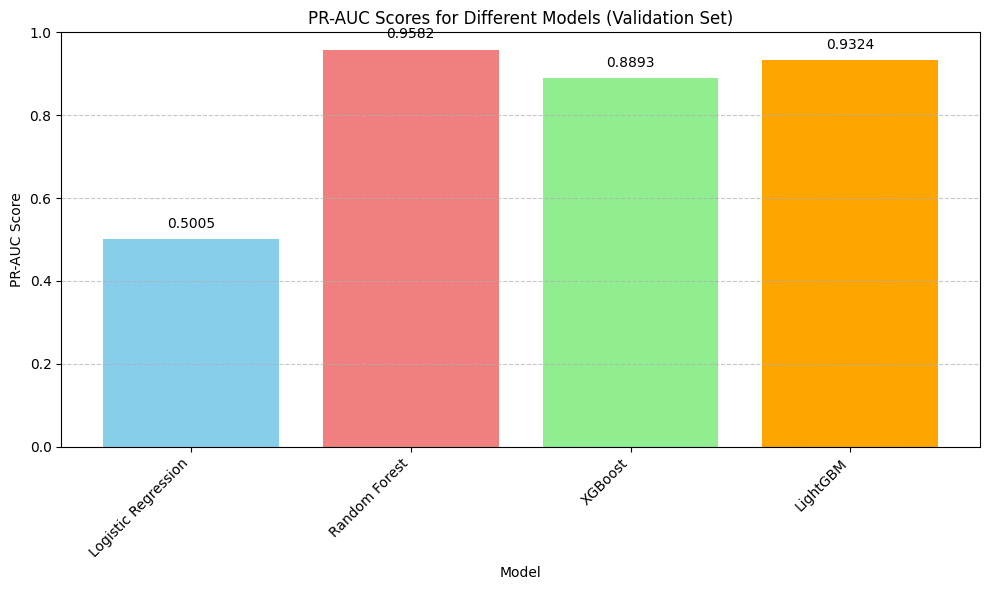

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(df_pr_auc['Model'], df_pr_auc['PR-AUC'], color=['skyblue', 'lightcoral', 'lightgreen', 'orange'])
plt.xlabel('Model')
plt.ylabel('PR-AUC Score')
plt.title('PR-AUC Scores for Different Models (Validation Set)')
plt.ylim(0, 1) # PR-AUC scores are between 0 and 1

# Add score labels on top of the bars
for index, row in df_pr_auc.iterrows():
    plt.text(index, row['PR-AUC'] + 0.02, f"{row['PR-AUC']:.4f}", ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
end_time = time.time()
total_time = end_time - start_time
print(f"total elapsed time: {total_time}")


total elapsed time: 5963.844186782837


In [ ]:
import platform
import psutil

print("CPU Information:")
!lscpu

print("\nCPU Usage (current):")
print(f"CPU Percent: {psutil.cpu_percent(interval=1)}%")
print(f"CPU Count (logical): {psutil.cpu_count(logical=True)}")
print(f"CPU Count (physical): {psutil.cpu_count(logical=False)}")

CPU Information:
Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      2
  On-line CPU(s) list:       0,1
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:              6
    Model:                   79
    Thread(s) per core:      2
    Core(s) per socket:      1
    Socket(s):               1
    Stepping:                0
    BogoMIPS:                4400.45
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
  